In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mengatur gaya visualisasi seaborn
sns.set_theme(style="whitegrid")

# Memuat dataset factory_production.csv
df = pd.read_csv('machine_downtime.csv')

# Menampilkan 10 baris pertama
df.head(10)

,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
0,DT0001,2025-09-03,M08,10.2,Kerusakan Elektrikal,70.5,98.2,Malam,NaN
1,DT0002,2025-11-11,M10,6.4,Kerusakan Mekanis,57.3,77.6,Malam,1149.0
2,DT0003,2025-09-21,M05,7.2,Kerusakan Mekanis,59.9,43.4,Pagi,820.0
3,DT0004,2025-08-23,M06,12.9,Kerusakan Mekanis,79.8,69.8,Siang,1757.0
4,DT0005,2026-01-14,M07,8.5,Kerusakan Mekanis,64.4,100.0,Pagi,787.0
5,DT0006,2025-10-03,M07,8.6,Kerusakan Mekanis,64.8,67.4,Malam,944.0
6,DT0007,2025-12-25,M06,12.9,Kerusakan Mekanis,79.9,100.0,Pagi,NaN
7,DT0008,2025-12-12,M04,11.3,Kerusakan Mekanis,74.3,87.4,Malam,1285.0
8,DT0009,2025-08-27,M09,6.1,Kekurangan Bahan Baku,56.0,65.9,Pagi,909.0
9,DT0010,2025-09-04,M08,10.7,Pergantian Alat (Tooling Change),72.1,55.8,Malam,1828.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Kejadian                  520 non-null    str    
 1   Tanggal_Kejadian             520 non-null    str    
 2   ID_Mesin                     520 non-null    str    
 3   Usia_Mesin_Tahun             520 non-null    float64
 4   Penyebab_Downtime            520 non-null    str    
 5   Durasi_Downtime_Menit        520 non-null    float64
 6   Beban_Kerja_Harian_Persen    520 non-null    float64
 7   Shift_Kejadian               520 non-null    str    
 8   Biaya_Perbaikan_Ribu_Rupiah  427 non-null    float64
dtypes: float64(4), str(5)
memory usage: 59.2 KB


In [4]:
df.describe()

,Usia_Mesin_Tahun,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Biaya_Perbaikan_Ribu_Rupiah
count,520.000000,520.000000,520.000000,427.000000
mean,7.645577,62.411538,71.403654,1053.231850
std,3.437073,9.724885,14.249577,401.454071
min,-8.600000,42.800000,20.000000,158.000000
25%,6.200000,56.600000,62.400000,774.000000
50%,7.100000,59.600000,71.550000,1048.000000
75%,10.500000,71.500000,81.300000,1321.000000
max,13.400000,81.600000,100.000000,2186.000000


In [5]:
df.isnull().sum()

ID_Kejadian                     0
Tanggal_Kejadian                0
ID_Mesin                        0
Usia_Mesin_Tahun                0
Penyebab_Downtime               0
Durasi_Downtime_Menit           0
Beban_Kerja_Harian_Persen       0
Shift_Kejadian                  0
Biaya_Perbaikan_Ribu_Rupiah    93
dtype: int64

In [7]:
df_clean = df.copy()

if 'Biaya_Perbaikan_Ribu_Rupiah' in df_clean.columns:
    median_biaya = df_clean['Biaya_Perbaikan_Ribu_Rupiah'].median()
    df_clean['Biaya_Perbaikan_Ribu_Rupiah'] = df_clean['Biaya_Perbaikan_Ribu_Rupiah'].fillna(median_biaya)

# 2. Menangani nilai negatif pada Usia_Mesin_Tahun
# Nilai negatif merupakan kesalahan input/pencatatan, maka dikoreksi menggunakan nilai absolut (abs)
if 'Usia_Mesin_Tahun' in df_clean.columns:
    df_clean['Usia_Mesin_Tahun'] = df_clean['Usia_Mesin_Tahun'].abs()

C:\Users\Mutia\AppData\Local\Temp\ipykernel_19144\2231033602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Penyebab_Downtime', order=df_clean['Penyebab_Downtime'].value_counts().index, palette='viridis')


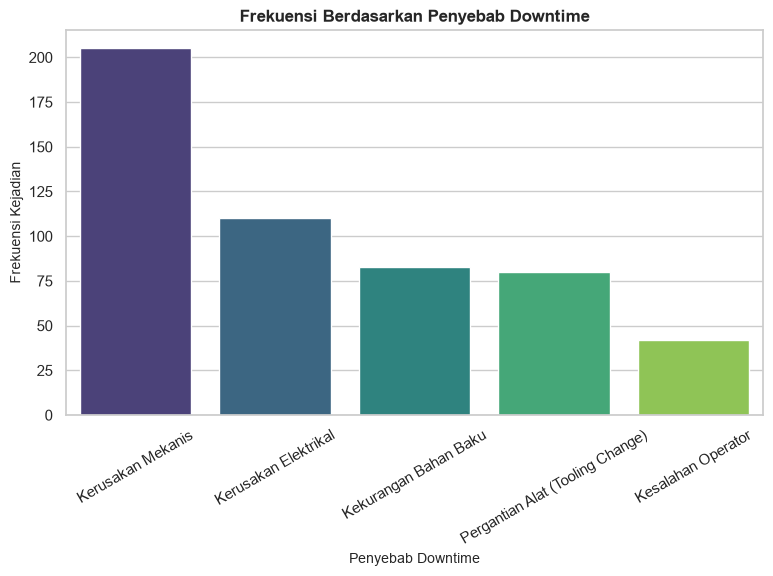

In [14]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x='Penyebab_Downtime', order=df_clean['Penyebab_Downtime'].value_counts().index, palette='viridis')
plt.title('Frekuensi Berdasarkan Penyebab Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Penyebab Downtime', fontsize=10)
plt.ylabel('Frekuensi Kejadian', fontsize=10)
plt.xticks(rotation=30)
plt.show()

C:\Users\Mutia\AppData\Local\Temp\ipykernel_19144\584411419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ID_Mesin', y='Durasi_Downtime_Menit', palette='Set2')


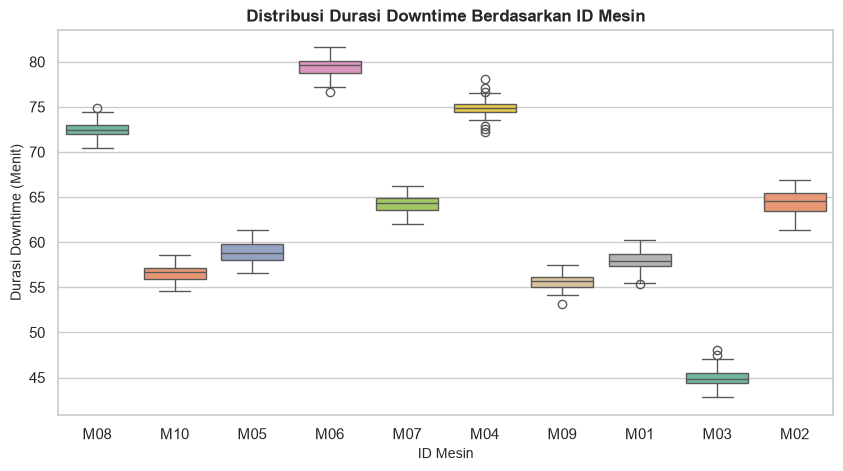

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='ID_Mesin', y='Durasi_Downtime_Menit', palette='Set2')
plt.title('Distribusi Durasi Downtime Berdasarkan ID Mesin', fontsize=12, fontweight='bold')
plt.xlabel('ID Mesin', fontsize=10)
plt.ylabel('Durasi Downtime (Menit)', fontsize=10)
plt.show()

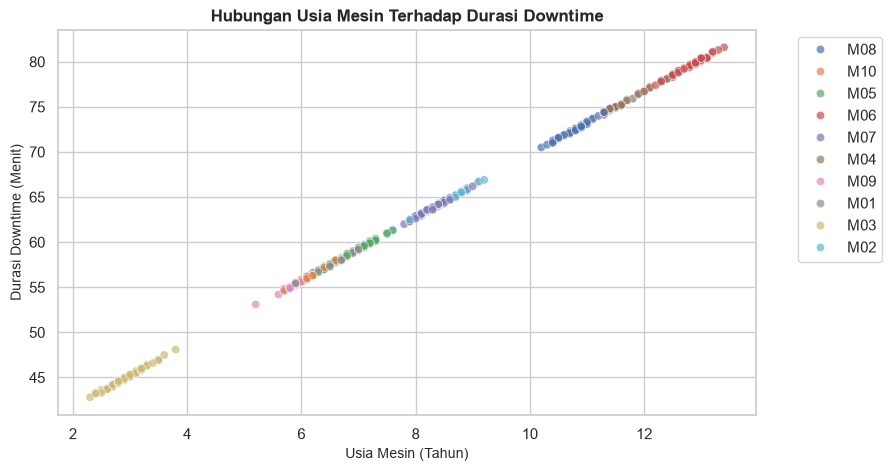

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='Usia_Mesin_Tahun', y='Durasi_Downtime_Menit', hue='ID_Mesin', alpha=0.7, palette='deep')
plt.title('Hubungan Usia Mesin Terhadap Durasi Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Usia Mesin (Tahun)', fontsize=10)
plt.ylabel('Durasi Downtime (Menit)', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()